<font size="+3"><strong>バリアント単位での配列データの準備</strong></font>

データを複数条件でフィルタリングし、配列情報を追加して出力する。

---

コード部分の最終更新日: 2024-08-26

 <font color="red" size="+1">注意事項：デバッグ不足</font>
 


---
---
# インポート
---

使いまわしているので、不要なライブラリのimportを含む。


In [1]:
# 汎用ライブラリのimport
import os
import sys
import copy
import warnings
import textwrap
from operator import itemgetter
from collections import Counter
import logging

import math
import random

import platform
import locale
import gzip
import io
import hashlib
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import __version__ as matplotlib_version

import sylib

# %config Completer.use_jedi = False
# %matplotlib inline

progress_bar = sylib.utils.ProgressBar()

# Jupyterでlog出力するための特殊な設定
# StreamHandlerの出力先としてsys.stderrを指定している。
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
#     level=logging.DEBUG,
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler]
)
logger=logging.getLogger()

print("python = %d.%d.%d" % sys.version_info[:3])
print("pandas = %s" % pd.__version__)
print("numpy = %s" % np.__version__)
print("matplotlib = %s" % matplotlib_version)

print("sylib = %s" % sylib.__version__)


python = 3.11.9
pandas = 2.2.2
numpy = 1.26.4
matplotlib = 3.9.0
sylib = 0.3.0.dev0+ae18bb2


---
---
# 図の全体的な設定
---


In [2]:
# 一度図を作ってrcParamsを呼び込まないとrcParamsの変更が反映されない場合がある
fig = plt.figure()
plt.close()

# フォントサイズの指定です。
plt_font_size = 16
plt.rcParams['font.size'] = plt_font_size

# フォント名の指定です。フォントはインストールされているものに限ります。
# japanize_matplotlibを用いて日本語を表示している場合、
# フォントを不適切に再設定すると日本語が表示されなくなります。
# Colabを用いる場合はフォントのインストールや登録が必要となりハードルが高いです。
# Colabを用いる場合、初心者は変更せずに使いましょう。
# フォントを変更する場合は以下のコメントアウトを外してください。
# font.family以下はフォント名の設定を色々な要素に反映させるための記述です（変更不要）。
# plt.rcParams['font.serif'] = "DejaVu Sans"
# plt.rcParams['font.family'] = "serif"
# plt.rcParams['mathtext.cal'] = "serif:italic"
# plt.rcParams['mathtext.rm'] = "serif"
# plt.rcParams['mathtext.it'] = "serif:italic"
# plt.rcParams['mathtext.bf'] = "serif:bold"
# plt.rcParams['mathtext.fontset'] = "custom"

# グリッド線などを正しく表示するための設定です。
plt.rcParams['axes.axisbelow'] = True

# 図の解像度を上げるための設定です。
# 表示される図が大きくなるので動作をテストする際には小さい値のほうが見やすいです。
# 最終的に使用する図を出力する際には300など大きな数字を設定しましょう。
# 初期値は72です。
plt.rcParams["figure.dpi"] = 72
# plt.rcParams["figure.dpi"] = 300

# OKという表示があることを確認してください。
print("OK")


OK


---
---
# 出力フォルダの準備
---


In [3]:
output_dir = sylib.utils.make_dir("SeqData.Var", should_clear=False)


---
---
# inputデータ形式の確認
---

---
## Transデータについて

### rTSS-pos0b, rTSS-usage, rCPS-pos0b, rCPS-usage

- そのスプライスバリアントにおける、最も主要なサイトの位置とその存在比率を計算している
- 使用頻度の計算時の分母は「そのスプライスバリアント」

### TSS-data, CPS-data, TSS-CPS-data

- 各末端位置における`[[各タイムポイントのリード数のリスト], slope, n_time_points, time_code, slope_stderr]`が辞書形式でまとめられている
- TSS-dataはCPSは無視してTSSの位置だけでリードを集計して計算した結果
- CPS-dataはTSSは無視してCPSの位置だけでリードを集計して計算した結果
- TSS-CPS-dataは、両末端のペアごとにリードを集計して計算した結果



In [4]:
file_path = os.path.join("AT22.PR.trans_data.tsv.gz")

data_df, metadata = sylib.fileio.load_df(
    file_path, encoding="utf-8",
    delimiter='\t', comment="#",
    header='infer', names=None, index_col=None,
)
metadata.print_minimum_data(label="Input data", logger=logger, logging_level="info")
display(data_df.head(10))

print(list(enumerate(data_df.columns)))

del data_df


2024-08-26 11:06:43,587     INFO: Input data |   name = AT22.PR.trans_data.tsv.gz
2024-08-26 11:06:43,589     INFO: Input data |    md5 = 6fcb6b139c7e83fb42a35e72016cfe5c
2024-08-26 11:06:43,589     INFO: Input data | md5_gz = 5644219c1183afc2e6720dd8541a35b0


,trans_id,gene_id,chrom,strand,PTPM,TPM,PR_trans,P_n_reads,T_n_reads,trans-usage.a,...,TSS-data,CPS-data,TSS-CPS-data,P-PairDep-pvalue,P-PairDep-RelStats,T-PairDep-pvalue,T-PairDep-RelStats,coding_region,ref_cigar_s0b,ref_cigar
0,AT1G01010.1,AT1G01010,Chr1,+,0.203070,0.063154,3.273761,2,1,1.000000,...,"{3638: [1, 0, None], 3667: [1, 1, 1.6368806588...","{5846: [0, 1, 0.0], 5878: [1, 0, None], 5896: ...","{'3638,5878': [1, 0, None], '3667,5846': [0, 1...",1.000000,0.000000,1.000000,0.000000,"[3759, 5630]",3630,283M82N281M209N120M100N390M78N153M112N461M
1,AT1G01020.1,AT1G01020,Chr1,-,3.147589,1.705165,1.879381,31,27,0.482143,...,"{8667: [0, 1, 0.0], 8669: [1, 0, None], 8670: ...","{6342: [1, 0, None], 6790: [1, 0, None], 6795:...","{'8667,6882': [0, 1, 0.0], '8669,6342': [1, 0,...",1.000000,0.000000,1.000000,0.000000,"[6914, 8666]",6787,282M87N76M151N67M113N86M112N74M106N46M248N90M9...
2,AT1G01020.3,AT1G01020,Chr1,-,0.000000,0.063154,0.000000,0,1,0.017857,...,"{8677: [0, 1, 0.0]}","{6856: [0, 1, 0.0]}","{'8677,6856': [0, 1, 0.0]}",1.000000,0.000000,1.000000,0.000000,"[6914, 8442]",6787,282M87N76M151N67M113N86M112N74M106N46M248N229M...
3,AT1G01020.5,AT1G01020,Chr1,-,1.319957,1.768319,0.759980,13,28,0.500000,...,"{8662: [0, 1, 0.0], 8671: [1, 0, None], 8672: ...","{6790: [0, 1, 0.0], 6828: [1, 0, None], 6833: ...","{'8662,6877': [0, 1, 0.0], '8671,6859': [1, 0,...",1.000000,0.000000,1.000000,0.000000,"[6914, 8419]",6787,282M87N76M151N67M113N86M112N74M106N46M248N90M9...
4,AT1G01050.1,AT1G01050,Chr1,-,244.293523,204.872427,1.214037,2406,3244,1.000000,...,"{33045: [1, 3, 0.5456268862702276], 33046: [1,...","{31053: [0, 1, 0.0], 31061: [2, 3, 1.091253772...","{'33045,31181': [1, 0, None], '33045,31197': [...",0.917975,0.019254,0.979973,0.017847,"[31381, 32670]",31169,255M96N82M90N121M119N66M89N108M86N66M83N29M87N...
5,AT1G01060.2,AT1G01060,Chr1,-,0.000000,0.063154,0.000000,0,1,0.500000,...,"{37398: [0, 1, 0.0]}","{33761: [0, 1, 0.0]}","{'37398,33761': [0, 1, 0.0]}",1.000000,0.000000,1.000000,0.000000,"[33991, 37061]",33665,662M73N1074M92N81M82N234M660N62M124N112M101N18...
6,AT1G01060.4,AT1G01060,Chr1,-,0.000000,0.063154,0.000000,0,1,0.500000,...,"{37734: [0, 1, 0.0]}","{33745: [0, 1, 0.0]}","{'37734,33745': [0, 1, 0.0]}",1.000000,0.000000,1.000000,0.000000,"[33991, 37061]",33665,662M73N1071M95N81M82N234M660N62M124N112M101N18...
7,AT1G01080.1,AT1G01080,Chr1,-,3.756800,2.905096,1.316621,37,46,0.807018,...,"{46791: [2, 0, None], 46802: [1, 1, 1.63688065...","{45264: [1, 0, None], 45292: [2, 1, 3.27376131...","{'46791,45295': [1, 0, None], '46791,45382': [...",1.000000,0.000000,1.000000,0.000000,"[45502, 46789]",44969,590M86N309M89N102M230N684M
8,AT1G01080.2,AT1G01080,Chr1,-,0.101535,0.063154,1.636881,1,1,0.017544,...,"{46800: [1, 0, None], 46828: [0, 1, 0.0]}","{45343: [0, 1, 0.0], 45352: [1, 0, None]}","{'46800,45352': [1, 0, None], '46828,45343': [...",1.000000,0.000000,1.000000,0.000000,"[45502, 46789]",45295,264M86N309M89N102M227N647M
9,AT1G01080.3,AT1G01080,Chr1,-,0.304605,0.631543,0.491064,3,10,0.175439,...,"{46791: [0, 1, 0.0], 46800: [1, 0, None], 4682...","{45260: [0, 2, 0.0], 45293: [1, 0, None], 4529...","{'46791,45373': [0, 1, 0.0], '46800,45335': [1...",1.000000,0.000000,1.000000,0.000000,"[45609, 46789]",44969,985M89N102M230N684M


[(0, 'trans_id'), (1, 'gene_id'), (2, 'chrom'), (3, 'strand'), (4, 'PTPM'), (5, 'TPM'), (6, 'PR_trans'), (7, 'P_n_reads'), (8, 'T_n_reads'), (9, 'trans-usage.a'), (10, 'trans-usage.b'), (11, 'trans-usage.c'), (12, 'rTSS-pos0b'), (13, 'rTSS-usage'), (14, 'rCPS-pos1b'), (15, 'rCPS-usage'), (16, 'rTSS-CPS-pos'), (17, 'rTSS-CPS-usage'), (18, 'TSS-data'), (19, 'CPS-data'), (20, 'TSS-CPS-data'), (21, 'P-PairDep-pvalue'), (22, 'P-PairDep-RelStats'), (23, 'T-PairDep-pvalue'), (24, 'T-PairDep-RelStats'), (25, 'coding_region'), (26, 'ref_cigar_s0b'), (27, 'ref_cigar')]


---
---
# リファレンスゲノム情報の読み込み
---


In [5]:
# file_path = os.path.join("..", "ReferenceGenome", "gfd0", "Araport11_GFF3_genes_transposons.201606.std_r_luc.gfd.gz")
# gfd0_data, metadata = sylib.fileio.load_json(
#     file_path, encoding="utf-8"
# )
# metadata.print_minimum_data(label="GFD0 data", logger=logger)

file_path = os.path.join("..", "ReferenceGenome", "Arabidopsis_thaliana.Araport11.std_r_luc.fa")
fasta_data, metadata = sylib.fileio.load_fasta(file_path)
metadata.print_minimum_data(label="FASTA data", logger=logger)


---
---
# 定数と関数
---

**古田さんのデータを算出時とは一部のコードが異なる。**

以下を追加し、GGGの判定を先に変更した（古田さんの場合以下は、非YRとして扱われているので排除されるという結果に変わりはない）

~~~Python
            if up_ggg_seq[-2:] == "GG" and utr5_seq[0] == "G":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
            if up_ggg_seq[-1] == "G" and utr5_seq[:2] == "GG":
                n_reads_dict["GGG-TSS"] += 1
                progress_bar.increase(1)
                continue
~~~


In [10]:
# DAME_CHROM_SET = {"ChrC", "ChrM"}
DAME_CHROM_SET = {"std_r_luc_expr_cassette"}


def get_upstream_seq(chrom, strand, tss_pos0b, seq_len=1000):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b-seq_len, tss_pos0b, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b+1, tss_pos0b+1+seq_len, reverse_complement=(strand=="-")
        )
    return seq


def get_gene_seq(chrom, strand, tss_pos0b, cps_pos1b):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, tss_pos0b, cps_pos1b, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b-1, tss_pos0b+1, reverse_complement=(strand=="-")
        )
    return seq


def get_downstream_seq(chrom, strand, cps_pos1b, seq_len=1000):
    if strand == "+":
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b, cps_pos1b+seq_len, reverse_complement=(strand=="-")
        )
    else:
        seq = fasta_data.get_sequence(
            chrom, cps_pos1b-1-seq_len, cps_pos1b-1, reverse_complement=(strand=="-")
        )
    return seq


def get_5utr_seq(chrom, strand, tss_pos0b, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    if strand == "+":
        if coding_region[0] == ref_cigar_s0b:
            cigar = [[coding_region[0]-tss_pos0b, "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, tss_pos0b, coding_region[0], cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr5_seq = fasta_data.get_seq_from_cigar(
            chrom, tss_pos0b, cigar, reverse_complement=(strand=="-")
        )
    else:
        if coding_region[1] == ref_cigar_e1b:
            cigar = [[tss_pos0b+1-coding_region[1], "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, coding_region[1], tss_pos0b+1, cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr5_seq = fasta_data.get_seq_from_cigar(
            chrom, coding_region[1], cigar, reverse_complement=(strand=="-")
        )
    n_5utr_introns = len([_ for _, char in cigar if char == "N"])
    return utr5_seq, n_5utr_introns


def get_cds_seq(chrom, strand, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
        ref_cigar, coding_region[0], coding_region[1], cigar_s0b=ref_cigar_s0b,
        should_ignore_region_warning=True
    )
    cds_seq = fasta_data.get_seq_from_cigar(
        chrom, coding_region[0], cigar, reverse_complement=(strand=="-")
    )
    n_cds_introns = len([_ for _, char in cigar if char == "N"])
    return cds_seq, n_cds_introns


def get_3utr_seq(chrom, strand, cps_pos1b, ref_cigar, ref_cigar_s0b, ref_cigar_e1b, coding_region):
    if strand == "+":
        if coding_region[1] == ref_cigar_e1b:
            cigar = [[cps_pos1b-coding_region[1], "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, coding_region[1], cps_pos1b, cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr3_seq = fasta_data.get_seq_from_cigar(
            chrom, coding_region[1], cigar, reverse_complement=(strand=="-")
        )
    else:
        if coding_region[0] == ref_cigar_s0b:
            cigar = [[coding_region[0]-cps_pos1b-1, "M"]]
        else:
            cigar = sylib.sequtils.trim_cigar_at_ref_seq_pos(
                ref_cigar, cps_pos1b-1, coding_region[0], cigar_s0b=ref_cigar_s0b,
                should_ignore_region_warning=True
            )
        utr3_seq = fasta_data.get_seq_from_cigar(
            chrom, cps_pos1b-1, cigar, reverse_complement=(strand=="-")
        )
    n_3utr_introns = len([_ for _, char in cigar if char == "N"])
    return utr3_seq, n_3utr_introns


def main_process(
    file_path, output_file_path=None,
    n_reads_thresh=100,
    trans_usage_thresh=0.5,
    tss_usage_thresh=0.05, cps_usage_thresh=0.05,
    var_usage_thresh=0.01,
    should_output_dna=False,
    up_len=500, down_len=500,
    artifact_removal_level=0,
    target_strand=None
):

    data_df, metadata = sylib.fileio.load_df(
        file_path, encoding="utf-8",
        delimiter='\t', comment="#",
        header='infer', names=None, index_col=None,
    )
    metadata.print_data(label="Data", logger=logger, logging_level="info")
    # display(data_df)

    print("-"*120)    

    if should_output_dna:
        seq_df_dict = {
            "var_id": [],
            "trans_id": [],
            "gene_id": [],
            "usage": [],
            "PR_var": [],
            "Upstream": [],
            "Gene": [],
            "Downstream": [],
            "5'UTR": [],
            "CDS": [],
            "3'UTR": [],
            "n_5'UTR_introns": [],
            "n_CDS_introns": [],
            "n_3'UTR_introns": [],
        }
    else:
        seq_df_dict = {
            "var_id": [],
            "trans_id": [],
            "gene_id": [],
            "usage": [],
            "PR_var": [],
            "5'UTR": [],
            "CDS": [],
            "3'UTR": [],
            "n_5'UTR_introns": [],
            "n_CDS_introns": [],
            "n_3'UTR_introns": [],
        }
    
    n_reads_dict = {
        "input": len(data_df), "dame chrom": 0,
        "Low trans-usage": 0, "Low n_reads": 0,
        "Non-canonical": 0, "Error CDS": 0, "No PR_var": 0,
        "output": 0
    }
    n_var_dict = {
        "Input": 0, "Low TSS-usage": 0, "Low CPS-usage": 0,
        "Low var-usage": 0, "Low n_reads": 0, "P n_reads == 0": 0,
        "Non-canonical": 0, "Truncated": 0,
        "GGG-TSS": 0, "Non-YR": 0, "Downstream-polyA": 0,
        "Output": 0
    }
    non_yr_counter = Counter()
    progress_bar.set_total_steps(len(data_df))
    for i in range(len(data_df)):
        data_sr = data_df.iloc[i, :]
        trans_id = data_sr["trans_id"]
        gene_id = data_sr["gene_id"]
        chrom = data_sr["chrom"]
        strand = data_sr["strand"]
        if chrom in DAME_CHROM_SET:
            n_reads_dict["dame chrom"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["trans-usage.b"] < trans_usage_thresh:
            n_reads_dict["Low trans-usage"] += 1
            progress_bar.increase(1)
            continue
        if data_sr["T_n_reads"] < n_reads_thresh:
            n_reads_dict["Low n_reads"] += 1
            progress_bar.increase(1)
            continue
        if target_strand == "+" and strand == "-":
            progress_bar.increase(1)
            continue
        if target_strand == "-" and strand == "+":
            progress_bar.increase(1)
            continue

        coding_region = eval(data_sr["coding_region"])
        ref_cigar = sylib.sequtils.parse_cigar(data_sr["ref_cigar"])
        ref_cigar_s0b = data_sr["ref_cigar_s0b"]
        ref_cigar_e1b = sylib.sequtils.get_ref_end1b_pos_from_cigar(ref_cigar, ref_cigar_s0b)
        get_seq_kwargs = {
            "chrom": chrom, "strand": strand, "ref_cigar":ref_cigar,
            "ref_cigar_s0b": ref_cigar_s0b, "ref_cigar_e1b": ref_cigar_e1b, "coding_region":coding_region
        }
        
        cds_seq, n_cds_introns = get_cds_seq(**get_seq_kwargs)
        if sylib.sequtils.detect_noncanon_nuc(cds_seq)["canonical"] != len(cds_seq):
            n_reads_dict["Non-canonical"] += 1
            progress_bar.increase(1)
            continue
        if sylib.sequtils.translate_to_aa_seq(cds_seq)[1] != 0:
            n_reads_dict["Error CDS"] += 1
            progress_bar.increase(1)
            continue

        t_n_reads = data_sr["T_n_reads"]
        pair_data = eval(data_sr["TSS-CPS-data"])

        # P n_reads, T n_reads, PR
        tss_usage_dict = {
            pos: n/t_n_reads
            for pos, (_, n, _) in eval(data_sr["TSS-data"]).items()
        }

        # P n_reads, T n_reads, PR
        cps_usage_dict = {
            pos: n/t_n_reads
            for pos, (_, n, _) in eval(data_sr["CPS-data"]).items()
        }
        
        n_seqs = 0
        for pos, val_list in pair_data.items():
            n_var_dict["Input"] += 1
            tss_pos0b, cps_pos1b = pos.split(",")
            tss_pos0b, cps_pos1b = int(tss_pos0b), int(cps_pos1b)
            p_n_reads_site = val_list[0]
            t_n_reads_site = val_list[1]
            usage = t_n_reads_site/t_n_reads
            if tss_usage_dict[tss_pos0b] < tss_usage_thresh:
                n_var_dict["Low TSS-usage"] += 1
                continue
            if cps_usage_dict[cps_pos1b] < cps_usage_thresh:
                n_var_dict["Low CPS-usage"] += 1
                continue
            if usage < var_usage_thresh:
                n_var_dict["Low var-usage"] += 1
                continue
            if p_n_reads_site == 0:
                n_var_dict["P n_reads == 0"] += 1
                continue
            if t_n_reads_site < n_reads_thresh:
                n_var_dict["Low n_reads"] += 1
                continue

            up_seq = get_upstream_seq(chrom, strand, tss_pos0b, seq_len=up_len)
            if should_output_dna:
                gene_seq = get_gene_seq(chrom, strand, tss_pos0b, cps_pos1b)
            down_seq = get_downstream_seq(chrom, strand, cps_pos1b, seq_len=down_len)
            if should_output_dna:
                if sylib.sequtils.detect_noncanon_nuc(up_seq)["canonical"] != len(up_seq):
                    n_var_dict["Non-canonical"] += 1
                    continue
                if sylib.sequtils.detect_noncanon_nuc(gene_seq)["canonical"] != len(gene_seq):
                    n_var_dict["Non-canonical"] += 1
                    continue
                if sylib.sequtils.detect_noncanon_nuc(down_seq)["canonical"] != len(down_seq):
                    n_var_dict["Non-canonical"] += 1
                    continue
            if len(up_seq) != up_len or len(down_seq) != down_len:
                n_var_dict["Truncated"] += 1
                continue
            utr5_seq, n_5utr_introns = get_5utr_seq(
                tss_pos0b=tss_pos0b, **get_seq_kwargs
            )
            if sylib.sequtils.detect_noncanon_nuc(utr5_seq)["canonical"] != len(utr5_seq):
                n_var_dict["Non-canonical"] += 1
                continue
            utr3_seq, n_3utr_introns = get_3utr_seq(
                cps_pos1b=cps_pos1b, **get_seq_kwargs
            )
            if sylib.sequtils.detect_noncanon_nuc(utr3_seq)["canonical"] != len(utr3_seq):
                n_var_dict["Non-canonical"] += 1
                continue

            # シーケンシングアーティファクト疑惑のサイトの削除
            if artifact_removal_level > 0:
                up_ggg_seq = get_upstream_seq(chrom, strand, tss_pos0b, seq_len=3)
                down_pa_seq = get_downstream_seq(chrom, strand, cps_pos1b, seq_len=10)
                if up_ggg_seq == "GGG" or utr5_seq[:3] == "GGG":
                    n_var_dict["GGG-TSS"] += 1
                    continue
                if up_ggg_seq[-2:] == "GG" and utr5_seq[0] == "G":
                    n_var_dict["GGG-TSS"] += 1
                    continue
                if up_ggg_seq[-1] == "G" and utr5_seq[:2] == "GG":
                    n_var_dict["GGG-TSS"] += 1
                    continue
                if artifact_removal_level > 1:
                    if up_ggg_seq[-1] not in {"T", "U", "C"}:
                        n_var_dict["Non-YR"] += 1
                        non_yr_counter[up_ggg_seq[-1]+utr5_seq[0]] += 1
                        continue
                    if utr5_seq[0] not in {"A", "G"}:
                        n_var_dict["Non-YR"] += 1
                        non_yr_counter[up_ggg_seq[-1]+utr5_seq[0]] += 1
                        continue
                if down_pa_seq.count("A") >= 7:
                    n_var_dict["Downstream-polyA"] += 1
                    continue

            seq_df_dict["var_id"].append("%s.%s.%s" % (trans_id, tss_pos0b, cps_pos1b))
            seq_df_dict["trans_id"].append(trans_id)
            seq_df_dict["gene_id"].append(gene_id)
            seq_df_dict["usage"].append(usage)
            seq_df_dict["PR_var"].append(val_list[2])
            if should_output_dna:
                seq_df_dict["Upstream"].append(up_seq.upper())
                seq_df_dict["Gene"].append(gene_seq.upper())
                seq_df_dict["Downstream"].append(down_seq.upper())
            seq_df_dict["5'UTR"].append(utr5_seq.upper().replace("T", "U"))
            seq_df_dict["CDS"].append(cds_seq.upper().replace("T", "U"))
            seq_df_dict["3'UTR"].append(utr3_seq.upper().replace("T", "U"))
            seq_df_dict["n_5'UTR_introns"].append(n_5utr_introns)
            seq_df_dict["n_CDS_introns"].append(n_cds_introns)
            seq_df_dict["n_3'UTR_introns"].append(n_3utr_introns)
            n_seqs += 1
        progress_bar.increase(1)
        if n_seqs == 0:
            n_reads_dict["No PR_var"] += 1
    progress_bar.close()

    seq_df = pd.DataFrame(seq_df_dict)
    
    n_reads_dict["output"] = len(set(seq_df_dict["gene_id"]))
    for key, n_reads in n_reads_dict.items():
        print("%s = %s" % (key, n_reads))
    
    n_var_dict["Output"] = len(seq_df)
    for key, n_reads in n_var_dict.items():
        print("%s = %s" % (key, n_reads))

    print(non_yr_counter.most_common())

    if output_file_path is not None:
#         output_file_path = output_base_file_name + ".var_seq_data.tsv"
        metadata = sylib.fileio.write_df(
            seq_df, output_file_path, header_comment_list=None,
            footer_comment_list=None, encoding="utf-8",
            sep="\t", header=True, index=False, lineterminator="\n",
            gzip_mtime=0
        )
        metadata.print_minimum_data(label="Output seq data", logger=logger, logging_level="info")

        display(seq_df)

        print(list(enumerate(seq_df.columns)))
    return seq_df


---
---
# 実行
---

**古田さんとは閾値が一部異なるので注意**


---
## 閾値について

- n_reads_thresh: 0.0hデータで得られたリード数がこの値より小さいデータは排除する
- trans_usage_thresh: そのスプライスバリアントの比率（rTrans-usage）がこの値より小さいデータは排除する。この値が小さいことは、マイナーなスプライスバリアントのデータであることを意味する。
- tss_usage_thresh: そのバリアントのTSSの使用頻度がこの値より小さいデータは排除する。この値が小さいことは、マイナーな転写開始点由来のデータであり、アーティファクトや分解中間産物等の可能性が高いことを意味する。また、遺伝子発現制御への影響量を考えた場合、出現頻度が低く影響が小さいデータを解析する意味はあまりない。
- cps_usage_thresh: そのバリアントのCPSの使用頻度がこの値より小さいデータは排除する。tss_usage_threshと同様。
- var_usage_thresh: そのバリアントの出現頻度がこの値より小さいデータは排除する。例えば、十分な頻度で使用されているTSSやCPSであっても、その組み合わせとなるバリアントの出現頻度が低い場合は除去される。TSS-A, Bがそれぞれ50%、CPS-C, Dがそれぞれ50%あるが、A-C, A-D, B-C, B-Dの組み合わせがそれぞれ25%ではなく、A-C 49%、A-D 1%、B-C 1%、B-D 49%という偏りが生じている可能性があるために、TSS、CPSの判断とは独立して組み合わせの判断を行う。
- artifact_removal_level: Nanoporeシーケンシング特有のアーティファクトを除去するレベル。
    - 0: 一切の除去を行わない
    - 1: TSS周辺がGGGの場合や、CPS下流がAリッチの配列を除去する。なお、左記の特性を有する内在性遺伝子も存在するため、アーティファクト以外のデータも除去してしまっている。
    - 2: TSS周辺がGGGの場合や、TSSが非YRの場合、CPS下流がAリッチの配列を除去する。非YR型のInrも一定数は存在するため、上記よりも更に、アーティファクト以外のデータも除去してしまっている。
他の値は変更する必要がない（他の解析用や過去の解析用）。

---
## データの正確性と数について

正確な解析を行うためには、「実際に存在するmRNA配列」における「そのmRNA配列の真の能力を評価したスコア」が必要となる。しかし、実際のデータには、断片リードやシーケンシングアーティファクトなどの「存在しないmRNA配列」が混入している。また、測定誤差というものが存在しており、データ数（リード数）が少ないデータほど誤差が大きくなるため、「評価した値と真の能力との乖離」が大きくなる可能性がある。そのため、正確なデータを得るためには、様々な閾値でデータをフィルタリングし、不正確なデータを排除する必要がある。

一方で、データ数も解析の精度を向上させる大きな要因であり、多少は存在しないデータや、測定誤差が存在しても、データ数が大きければ、データに存在する「傾向」は確かな形として現れる（多少の外れ値が数点あっても相関の有無はしっかりわかるイメージ）。逆にどれだけデータがきれいでもデータ数が少なければ、複雑なデータを解析することが難しくなる（極端な例：データ数が2点しかない場合、スコアが高いデータと低いデータの2つだけであり、両データ間に差がある特徴ならどれでもそのデータを説明付けられてしまうため重要な要素を解析することが不可能となる）

**つまり、正確な解析を行うためには、データの正確性とデータの数のバランスを適切に取る必要がある。しかし、どの閾値が適切なのかはなかなか判断が難しく、実際に解析してみないとわからない。**

<font color="red" size="+1">どの閾値が適切かわからないので、色々な閾値でデータを出力する。</font>

<font color="red" size="+1">高澤くんの半減期の解析での閾値を参考にする。</font>


---
## AT22


In [11]:
file_path = os.path.join("AT22.PR.trans_data.tsv.gz")
output_base_name = "AT22.PR_var"

for n in [10, 20, 50]:
    # Threshold strictness level: TSL
    # Artifact removal level: ARL
    for ar_level in [0]:

        output_file_path = os.path.join(
            output_dir,"%s.N%s-TSL0-ARL%s.RNA.seq_data.tsv.gz" % (output_base_name, n, ar_level)
        )
        _ = main_process(
            file_path, output_file_path,
            n_reads_thresh=n,
            trans_usage_thresh=0.05,
            tss_usage_thresh=0.05, cps_usage_thresh=0.05,
            var_usage_thresh=0.01,
            should_output_dna=False,
            up_len=500, down_len=500,
            artifact_removal_level=ar_level,
            target_strand=None
        )


2024-08-26 11:29:29,924     INFO: Data |             name = AT22.PR.trans_data.tsv.gz
2024-08-26 11:29:29,924     INFO: Data |              md5 = 6fcb6b139c7e83fb42a35e72016cfe5c
2024-08-26 11:29:29,924     INFO: Data |           md5_gz = 5644219c1183afc2e6720dd8541a35b0
2024-08-26 11:29:29,924     INFO: Data |   number_of_data = 22512
2024-08-26 11:29:29,924     INFO: Data | column_name_list = ['trans_id', 'gene_id', 'chrom', 'strand', 'PTPM', 'TPM', 'PR_trans', 'P_n_reads', 'T_n_reads', 'trans-usage.a', 'trans-usage.b', 'trans-usage.c', 'rTSS-pos0b', 'rTSS-usage', 'rCPS-pos1b', 'rCPS-usage', 'rTSS-CPS-pos', 'rTSS-CPS-usage', 'TSS-data', 'CPS-data', 'TSS-CPS-data', 'P-PairDep-pvalue', 'P-PairDep-RelStats', 'T-PairDep-pvalue', 'T-PairDep-RelStats', 'coding_region', 'ref_cigar_s0b', 'ref_cigar']


------------------------------------------------------------------------------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████| 22512/22512 [00:20<00:00, 1086.29it/s]


input = 22512
dame chrom = 1
Low trans-usage = 2615
Low n_reads = 7115
Non-canonical = 2
Error CDS = 20
No PR_var = 9201
output = 3425
Input = 2576060
Low TSS-usage = 1763779
Low CPS-usage = 622802
Low var-usage = 55585
Low n_reads = 38608
P n_reads == 0 = 76400
Non-canonical = 0
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
Output = 18886
[]


2024-08-26 11:29:53,241     INFO: Output seq data |   name = AT22.PR_var.N10-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:29:53,241     INFO: Output seq data |    md5 = 8fc12df79844dd4b15360e885d940955
2024-08-26 11:29:53,241     INFO: Output seq data | md5_gz = ec157f2b7089a9d451b4b13cba5506bb


...

100%|██████████████████████████████████████████████████████████████████████████| 22512/22512 [00:16<00:00, 1391.31it/s]


input = 22512
dame chrom = 1
Low trans-usage = 2615
Low n_reads = 12854
Non-canonical = 0
Error CDS = 12
No PR_var = 5841
output = 1165
Input = 2366903
Low TSS-usage = 1668341
Low CPS-usage = 582167
Low var-usage = 46217
Low n_reads = 43419
P n_reads == 0 = 20979
Non-canonical = 0
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
Output = 5780
[]


2024-08-26 11:30:33,782     INFO: Output seq data |   name = AT22.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:30:33,782     INFO: Output seq data |    md5 = e0fbe97759058d5c815bdfcba6d870ac
2024-08-26 11:30:33,782     INFO: Output seq data | md5_gz = dc1a0f0747fb8b95c7e7fd3fcf1e8afe


,var_id,trans_id,gene_id,usage,PR_var,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G01050.1.33111.31207,AT1G01050.1,AT1G01050,0.023428,1.292274,GCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGAUA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
1,AT1G01050.1.33112.31207,AT1G01050.1,AT1G01050,0.025894,1.266634,GGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGAU...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
2,AT1G01050.1.33113.31181,AT1G01050.1,AT1G01050,0.020962,0.914727,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
3,AT1G01050.1.33113.31203,AT1G01050.1,AT1G01050,0.034525,1.169200,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
4,AT1G01050.1.33113.31207,AT1G01050.1,AT1G01050,0.077374,1.330373,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
...,...,...,...,...,...,...,...,...,...,...,...
5775,AT5G67590.1.26958028.26959517,AT5G67590.1,AT5G67590,0.022147,0.912876,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0
5776,AT5G67590.1.26958028.26959523,AT5G67590.1,AT5G67590,0.033220,1.133225,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0
5777,AT5G67590.1.26958028.26959555,AT5G67590.1,AT5G67590,0.072402,1.088044,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0
5778,AT5G67590.1.26958029.26959555,AT5G67590.1,AT5G67590,0.028961,1.516522,AAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0


[(0, 'var_id'), (1, 'trans_id'), (2, 'gene_id'), (3, 'usage'), (4, 'PR_var'), (5, "5'UTR"), (6, 'CDS'), (7, "3'UTR"), (8, "n_5'UTR_introns"), (9, 'n_CDS_introns'), (10, "n_3'UTR_introns")]


## AT35

- n_reads_thresh: Total RNA側で、この数値以上のリード以上検出されたバリアントのみを解析対象とする。分母となるリード数が低いとPR値のブレが大きいくなり、精度が下がる。一方で、この数値を大きくしすぎるとデータ数が下がる。
- trans_usage_thresh: 解析対象となるバリアントと同じスプライシングパターンを持つmRNAの比率が、この数値以上のもののみを解析対象とする。この数値が低い場合、非常に稀しか出現しないスプライシングパターンのデータであることを意味しており、何らかのシーケンシングエラーやマッピングエラー等の可能性が高くなる。
- var_usage_thresh: このバリアントが出現する比率が、この数値以上の物のみを解析対象とする。高蓄積mRNAの場合、低頻度でしか出現しないmRNAバリアントも50リードなどの閾値以上で検出されるが、あまりに出現頻度が低い場合は、何らかのシーケンシングエラーやマッピングエラーの可能性が高くなる。
- should_check_end_seq: もしTrueに設定すると、TSSがYRルール外のもの、5'末端の3塩基がGGGのもの、CPSの下流10塩基以内にAが7個以上出現するものは、逆転写やテンプレートスイッチ反応、PCR時に生じるアーティファクトの可能性があるため、除去する。
- should_output_dna, up_len, down_len, target_strand: 別の解析に用いていた設定値であり、今回は無視していい。

どの閾値が良いのか分からなかったので、とりあえず色々なパターンで出力してみる。


In [12]:
file_path = os.path.join("AT35.PR.trans_data.tsv.gz")
output_base_name = "AT35.PR_var"

for n in [10, 20, 50]:
    # Threshold strictness level: TSL
    # Artifact removal level: ARL
    for ar_level in [0]:

        output_file_path = os.path.join(
            output_dir,"%s.N%s-TSL0-ARL%s.RNA.seq_data.tsv.gz" % (output_base_name, n, ar_level)
        )
        _ = main_process(
            file_path, output_file_path,
            n_reads_thresh=n,
            trans_usage_thresh=0.05,
            tss_usage_thresh=0.05, cps_usage_thresh=0.05,
            var_usage_thresh=0.01,
            should_output_dna=False,
            up_len=500, down_len=500,
            artifact_removal_level=ar_level,
            target_strand=None
        )


2024-08-26 11:30:49,414     INFO: Data |             name = AT35.PR.trans_data.tsv.gz
2024-08-26 11:30:49,414     INFO: Data |              md5 = 4973645d049d85cfeda2adf05abd37a4
2024-08-26 11:30:49,414     INFO: Data |           md5_gz = 560080f42ae6921752fda29ccc0f8132
2024-08-26 11:30:49,414     INFO: Data |   number_of_data = 19593
2024-08-26 11:30:49,414     INFO: Data | column_name_list = ['trans_id', 'gene_id', 'chrom', 'strand', 'PTPM', 'TPM', 'PR_trans', 'P_n_reads', 'T_n_reads', 'trans-usage.a', 'trans-usage.b', 'trans-usage.c', 'rTSS-pos0b', 'rTSS-usage', 'rCPS-pos1b', 'rCPS-usage', 'rTSS-CPS-pos', 'rTSS-CPS-usage', 'TSS-data', 'CPS-data', 'TSS-CPS-data', 'P-PairDep-pvalue', 'P-PairDep-RelStats', 'T-PairDep-pvalue', 'T-PairDep-RelStats', 'coding_region', 'ref_cigar_s0b', 'ref_cigar']


------------------------------------------------------------------------------------------------------------------------


100%|██████████████████████████████████████████████████████████████████████████| 19593/19593 [00:16<00:00, 1212.23it/s]


input = 19593
dame chrom = 1
Low trans-usage = 1816
Low n_reads = 7693
Non-canonical = 0
Error CDS = 17
No PR_var = 7466
output = 2512
Input = 1985495
Low TSS-usage = 1317883
Low CPS-usage = 509037
Low var-usage = 48921
Low n_reads = 37385
P n_reads == 0 = 58497
Non-canonical = 0
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
Output = 13772
[]


2024-08-26 11:31:07,225     INFO: Output seq data |   name = AT35.PR_var.N10-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:31:07,225     INFO: Output seq data |    md5 = 591f40e3ebe95dfb6e63a8c1a61780ff
2024-08-26 11:31:07,226     INFO: Output seq data | md5_gz = 07be42f53561a10820b918ef68c2e63b


...

100%|██████████████████████████████████████████████████████████████████████████| 19593/19593 [00:12<00:00, 1626.25it/s]


input = 19593
dame chrom = 1
Low trans-usage = 1816
Low n_reads = 12630
Non-canonical = 0
Error CDS = 7
No PR_var = 4309
output = 812
Input = 1766091
Low TSS-usage = 1212539
Low CPS-usage = 463840
Low var-usage = 35889
Low n_reads = 36832
P n_reads == 0 = 12924
Non-canonical = 0
Truncated = 0
GGG-TSS = 0
Non-YR = 0
Downstream-polyA = 0
Output = 4067
[]


2024-08-26 11:31:37,531     INFO: Output seq data |   name = AT35.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:31:37,531     INFO: Output seq data |    md5 = c34871bff85688f610b4a46f219371ea
2024-08-26 11:31:37,535     INFO: Output seq data | md5_gz = 255efd093ac66361f84dbd9bd08af188


,var_id,trans_id,gene_id,usage,PR_var,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G01050.1.33113.31207,AT1G01050.1,AT1G01050,0.072715,0.767243,GGGCUUCACUUGUUUCUCUCCCAAAGUUUCUUCAUCAUCCUUGCGA...,AUGAGUGAAGAAACUAAAGAUAACCAGAGGCUGCAGCGACCAGCUC...,AGCUUCUCCUCAGAAGAUUUCUGCAGCAUCUAUGUUUCUGUUACUU...,1,7,0
1,AT1G01100.2.51178.50115,AT1G01100.2,AT1G01100,0.015780,0.637617,GAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGCAUUUUCGAUCUU...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
2,AT1G01100.2.51179.50115,AT1G01100.2,AT1G01100,0.020968,0.729013,AGAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGCAUUUUCGAUCU...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
3,AT1G01100.2.51179.50117,AT1G01100.2,AT1G01100,0.010808,0.519168,AGAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGCAUUUUCGAUCU...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
4,AT1G01100.2.51181.50115,AT1G01100.2,AT1G01100,0.028318,0.567135,CUAGAAAUUUUGUCUCUCUCGCCGCCUUGCGAAAAGCAUUUUCGAU...,AUGUCGACAGUUGGAGAGCUUGCUUGCAGCUACGCUGUUAUGAUCC...,ACGCAGUCACUUGUCUUUCUUCUUUGUAGUUGGAUAUUGGAGACUA...,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...
4062,AT5G67510.1.26938449.26937806,AT5G67510.1,AT5G67510,0.031158,0.709338,AGCACAAAAAAACCCUAAUUUCUUCACAAAUUCAGCGGCG,AUGAAGUUCAAUCCGCGUGUGAGCUCUUCUCGCCGGAAGAACAGGA...,UCUUAACGUAUGGUUUUUUCUUCUUCUUUUCUAGUUUUCUAUUUUG...,0,0,0
4063,AT5G67510.1.26938449.26937808,AT5G67510.1,AT5G67510,0.045855,0.527889,AGCACAAAAAAACCCUAAUUUCUUCACAAAUUCAGCGGCG,AUGAAGUUCAAUCCGCGUGUGAGCUCUUCUCGCCGGAAGAACAGGA...,UCUUAACGUAUGGUUUUUUCUUCUUCUUUUCUAGUUUUCUAUUUUG...,0,0,0
4064,AT5G67510.1.26938449.26937813,AT5G67510.1,AT5G67510,0.042916,0.882855,AGCACAAAAAAACCCUAAUUUCUUCACAAAUUCAGCGGCG,AUGAAGUUCAAUCCGCGUGUGAGCUCUUCUCGCCGGAAGAACAGGA...,UCUUAACGUAUGGUUUUUUCUUCUUCUUUUCUAGUUUUCUAUUUUG...,0,0,0
4065,AT5G67590.1.26958028.26959523,AT5G67590.1,AT5G67590,0.042584,0.509291,GAAAUCAAAAAGCUCAGCAAUUUUCCAGAUUUCUCUAAUUGACG,AUGGCGCUUUGUGCUACUACUCAAAGGACUAUCCGUAUAGCGGCGA...,UGUUACACCUUCUUCCAAUUCUUCUCGAGCAAAAGAAGAAACCUCA...,0,4,0


[(0, 'var_id'), (1, 'trans_id'), (2, 'gene_id'), (3, 'usage'), (4, 'PR_var'), (5, "5'UTR"), (6, 'CDS'), (7, "3'UTR"), (8, "n_5'UTR_introns"), (9, 'n_CDS_introns'), (10, "n_3'UTR_introns")]


---
---
# 配列データの確認
---


In [13]:
def plot_ax(data_df, ax, title_label=None, xlabel=None, ylabel=None):
    x = data_df.index

    ax.plot(x, data_df["A"], color='#CC0000',  linestyle='solid', label="A")
    ax.plot(x, data_df["U"], color='#008000',  linestyle='solid', label="T")
    ax.plot(x, data_df["G"], color='#FFB300',  linestyle='solid', label="G")
    ax.plot(x, data_df["C"], color='#0000CC',  linestyle='solid', label="C")

    if title_label is not None:
        ax.set_title(title_label, pad=font_size*2.5)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.grid(True)
#     ax.legend(bbox_to_anchor=(0.5, 1), loc="lower center", ncol=4, frameon=False)
    return


def plot_seqs(file_path, value_type=None):
    seq_df, metadata = sylib.fileio.load_df(file_path)
    file_name = sylib.utils.get_file_base_name(file_path)
    metadata.print_minimum_data(label="Seq data", logger=logger, logging_level="info")

    if value_type is None:
        suptitle = file_name
    else:
        if value_type == "top":
            seq_df = seq_df.sort_values(by='PR_var', ascending=False)
            suptitle = file_name + " Top seqs"
        else:
            seq_df = seq_df.sort_values(by='PR_var', ascending=True)
            suptitle = file_name + " Bottom seqs"

        seq_df = seq_df.head(int(len(seq_df) * 0.1))
        

    seq_len = 100
    pos_freq_df_dict1 = {nuc: [0]*seq_len for nuc in "AUGC"}
    pos_freq_df_dict2 = {nuc: [0]*seq_len for nuc in "AUGC"}
    pos_freq_df_dict3 = {nuc: [0]*seq_len for nuc in "AUGC"}

    def count_up_seq(seq, pos_freq_df_dict):
        for i in range(len(seq)):
            nuc = seq[i]
            if nuc == "-":
                continue
            try:
                pos_freq_df_dict[nuc][i] += 1
            except KeyError:
                if nuc in abnormal_nuc_dict:
                    abnormal_nuc_dict[nuc] += 1
                else:
                    abnormal_nuc_dict[nuc] = 1
        return

    abnormal_nuc_dict = {}
    for utr5, cds, utr3 in zip(seq_df["5'UTR"], seq_df["CDS"], seq_df["3'UTR"]):
        seq1 = utr5[:seq_len]
        seq1 += "-"*(seq_len-len(seq1))
        seq2 = utr5[-seq_len//2:]
        seq2 = "-"*(seq_len//2-len(seq2)) + seq2
        seq2 += cds[:seq_len//2]
        seq2 += "-"*(seq_len-len(seq2))
        seq1 += "-" * (seq_len-len(seq1))
        seq3 = utr3[-seq_len:]
        seq3 = "-"*(seq_len-len(seq3)) + seq3
        count_up_seq(seq1, pos_freq_df_dict1)
        count_up_seq(seq2, pos_freq_df_dict2)
        count_up_seq(seq3, pos_freq_df_dict3)

    if len(abnormal_nuc_dict) != 0:
        warnings.warn(
            "ATGC以外の塩基がある。%s" % abnormal_nuc_dict
        )

    pos_relfreq_df1 = pd.DataFrame(pos_freq_df_dict1)
    pos_relfreq_df1 = (pos_relfreq_df1.T/pos_relfreq_df1.sum(axis=1)).T
    pos_relfreq_df1.index = range(seq_len)

    pos_relfreq_df2 = pd.DataFrame(pos_freq_df_dict2)
    pos_relfreq_df2 = (pos_relfreq_df2.T/pos_relfreq_df2.sum(axis=1)).T
    pos_relfreq_df2.index = range(0-int(seq_len/2), int(seq_len/2))

    pos_relfreq_df3 = pd.DataFrame(pos_freq_df_dict3)
    pos_relfreq_df3 = (pos_relfreq_df3.T/pos_relfreq_df3.sum(axis=1)).T
    pos_relfreq_df3.index = range(-seq_len+1, 1)

    fig = plt.figure(figsize=(24/2.54, 8*3/2.54))
    ax1 = fig.add_subplot(3, 1, 1)
    plot_ax(pos_relfreq_df1, ax1, title_label=None, xlabel="Distance from 5'-end (nt)", ylabel="Relative frequency")
    ax1.set_ylim(0, 0.1)
    ax1.set_yticks(np.arange(0, 1.01, 0.2))
    ax1.set_xlim(-5, 105)
    ax1.set_xticks(range(0, 101, 10))

    ax2 = fig.add_subplot(3, 1, 2)
    plot_ax(pos_relfreq_df2, ax2, title_label=None, xlabel="Distance from [A]UG (nt)", ylabel="Relative frequency")
    ax2.set_ylim(0, 0.1)
    ax2.set_yticks(np.arange(0, 1.01, 0.2))
    ax2.set_xlim(-55, 55)
    ax2.set_xticks(range(-50, 51, 10))

    ax3 = fig.add_subplot(3, 1, 3)
    plot_ax(pos_relfreq_df3, ax3, title_label=None, xlabel="Distance from 3'-end (nt)", ylabel="Relative frequency")
    ax3.set_ylim(0, 0.1)
    ax3.set_yticks(np.arange(0, 1.01, 0.2))
    ax3.set_xlim(-105, 5)
    ax3.set_xticks(range(-100, 1, 10))

    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()
    plt.close()
    return


---
## いくつかの例（全データ）


2024-08-26 11:31:37,680     INFO: Seq data |   name = AT22.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:31:37,680     INFO: Seq data |    md5 = 24fdad91398c38940ec779900d7e1c6c
2024-08-26 11:31:37,680     INFO: Seq data | md5_gz = 75d7cc0ee223d4882dc9507b17a441e9


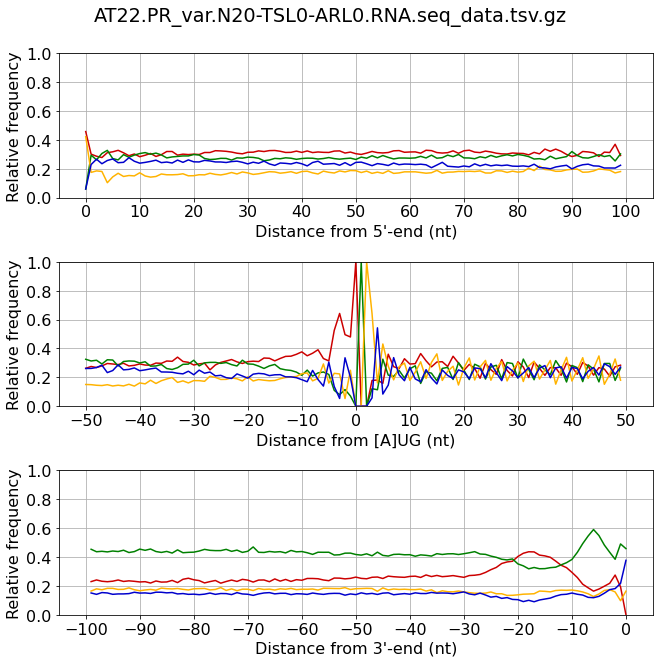

2024-08-26 11:31:38,111     INFO: Seq data |   name = AT35.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:31:38,111     INFO: Seq data |    md5 = 6301b15b21c39382c33b15c6fe513577
2024-08-26 11:31:38,111     INFO: Seq data | md5_gz = c92cecc288c6cac1abfba220573001c6


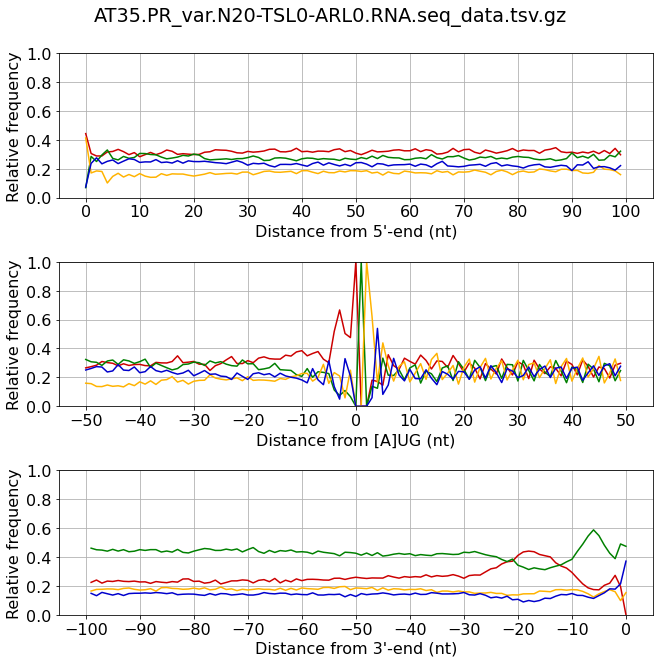

In [14]:
file_path_list = [
    os.path.join(output_dir, "AT22.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz"),
    os.path.join(output_dir, "AT35.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz"),
]
for file_path in file_path_list:
    plot_seqs(file_path, value_type=None)


---
## 上位と下位の例


2024-08-26 11:32:05,617     INFO: Seq data |   name = AT22.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:32:05,617     INFO: Seq data |    md5 = 24fdad91398c38940ec779900d7e1c6c
2024-08-26 11:32:05,617     INFO: Seq data | md5_gz = 75d7cc0ee223d4882dc9507b17a441e9


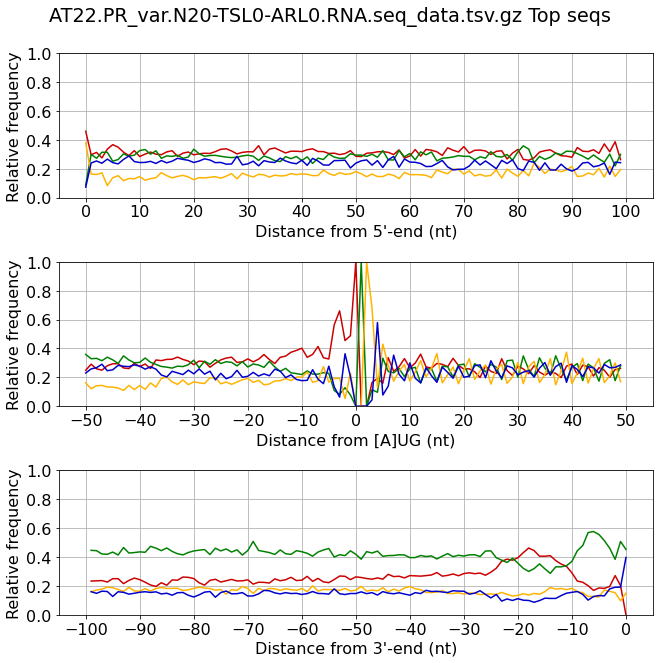

2024-08-26 11:32:05,908     INFO: Seq data |   name = AT22.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:32:05,908     INFO: Seq data |    md5 = 24fdad91398c38940ec779900d7e1c6c
2024-08-26 11:32:05,908     INFO: Seq data | md5_gz = 75d7cc0ee223d4882dc9507b17a441e9


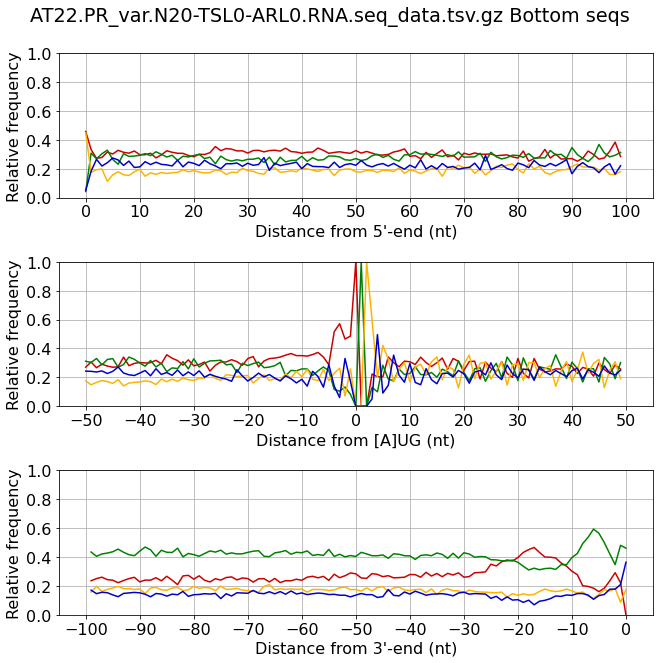

2024-08-26 11:32:06,176     INFO: Seq data |   name = AT35.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:32:06,176     INFO: Seq data |    md5 = 6301b15b21c39382c33b15c6fe513577
2024-08-26 11:32:06,176     INFO: Seq data | md5_gz = c92cecc288c6cac1abfba220573001c6


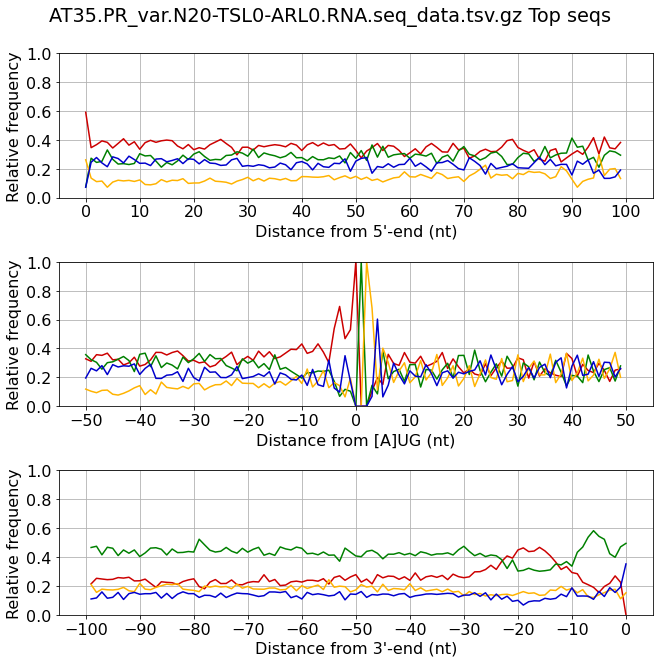

2024-08-26 11:32:06,408     INFO: Seq data |   name = AT35.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz
2024-08-26 11:32:06,409     INFO: Seq data |    md5 = 6301b15b21c39382c33b15c6fe513577
2024-08-26 11:32:06,409     INFO: Seq data | md5_gz = c92cecc288c6cac1abfba220573001c6


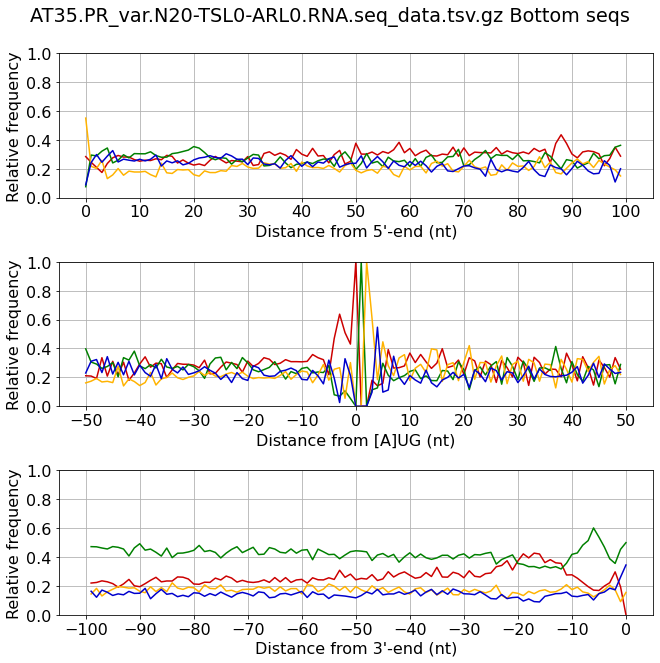

In [15]:
file_path = os.path.join(output_dir, "AT22.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz")

plot_seqs(file_path, value_type="top")
plot_seqs(file_path, value_type="bottom")

file_path = os.path.join(output_dir, "AT35.PR_var.N20-TSL0-ARL0.RNA.seq_data.tsv.gz")

plot_seqs(file_path, value_type="top")
plot_seqs(file_path, value_type="bottom")
